In [67]:
from datetime import datetime
import polars as pl
import numpy as np
import matplotlib.pyplot as plt


pl.Config.set_tbl_rows(-1)
pl.Config.set_decimal_separator(',')
pl.Config.set_thousands_separator('.')
pl.Config.set_float_precision(2)


ENDERECO_DADOS = './../../DADOS/bolsa_familia/'
ENDERECO_VOTACAO = './../../DADOS/votacao/'

# Obtendo os dados e filtrando os registros 13 e 22

In [68]:
# Obtendo os dados

try:
    # Lendo os dados do Bolsa Família
    df_bolsa_familia = pl.scan_parquet(ENDERECO_DADOS + 'bolsa_familia.parquet')
    # print(df_bolsa_familia)


    # Lendo os dados de votação
    df_dados_votacao = pl.read_csv(ENDERECO_VOTACAO + 'votacao_secao_2022_BR.csv', separator=';', encoding='iso-8859-1')
    print(df_dados_votacao.columns)
    # 'NR_VOTAVEL' 'NM_VOTAVEL' 'QT_VOTOS' 'NR_TURNO' 'SG_UF'
    
    # filtrar para segundo turno 'NR_TURNO' e 'NR_VOTAVEL' 13 e 22
    df_votacao_turno2 = df_dados_votacao.filter(
        (pl.col('NR_TURNO') == 2) & 
        (pl.col('NR_VOTAVEL').is_in([13, 22]))
    )

    print('Dados obtidos com sucesso')

except Exception as e:
    print(f"Erro ao ler os dados: {e}")

['DT_GERACAO', 'HH_GERACAO', 'ANO_ELEICAO', 'CD_TIPO_ELEICAO', 'NM_TIPO_ELEICAO', 'NR_TURNO', 'CD_ELEICAO', 'DS_ELEICAO', 'DT_ELEICAO', 'TP_ABRANGENCIA', 'SG_UF', 'SG_UE', 'NM_UE', 'CD_MUNICIPIO', 'NM_MUNICIPIO', 'NR_ZONA', 'NR_SECAO', 'CD_CARGO', 'DS_CARGO', 'NR_VOTAVEL', 'NM_VOTAVEL', 'QT_VOTOS', 'NR_LOCAL_VOTACAO', 'SQ_CANDIDATO', 'NM_LOCAL_VOTACAO', 'DS_LOCAL_VOTACAO_ENDERECO']
Dados obtidos com sucesso


In [69]:
# Processamento Votação
try:
    # Delimitar as variáveis, converter para Categorical, agrupar/totalizar e ordenar
    print()

    # Delimitar as variáveis 'SG_UF', 'NR_VOTAVEL', 'QT_VOTOS'
    df_votacao = df_votacao_turno2.lazy().select(['SG_UF', 'NM_VOTAVEL', 'QT_VOTOS'])
    # print(df_votacao)

    # Converter para Categorical
    df_votacao = df_votacao.with_columns([
        pl.col('SG_UF').cast(pl.Categorical),
        pl.col('NM_VOTAVEL').cast(pl.Categorical)
    ])

    # Agrupar/totalizar
    df_votacao = df_votacao.group_by(['SG_UF', 'NM_VOTAVEL']).agg(pl.sum('QT_VOTOS')).sort(['SG_UF', 'NM_VOTAVEL'])

    # coletar os dados
    # df_votacao = df_votacao.collect()
    # display(df_votacao) # print do jupyter
    # print(df_votacao)

except Exception as e:
    print(f"Erro no processamento dos dados de votação: {e}")

In [79]:
# Processamento Bolsa Família
try:
    # Delimitar as variáveis, converter em categorical, agrupar/totalizar e ordenar

    # delimitando as variaveis 'UF', 'VALOR PARCELA'
    df_bolsa_familia = df_bolsa_familia.lazy().select(['UF', 'VALOR PARCELA'])

    # converter para categorical
    df_bolsa_familia = df_bolsa_familia.with_columns([pl.col('UF').cast(pl.Categorical)])

    # Agrupar/totalizar
    df_bolsa_familia = df_bolsa_familia.group_by('UF').agg(pl.col('VALOR PARCELA').sum()).sort('UF', descending=False)

    # coletar os dados
    df_bolsa_familia = df_bolsa_familia.collect()
    # display(df_bolsa_familia)



except Exception as e:
    print(f"Erro no processamento dos dados do Bolsa Família: {e}")

In [74]:
# Realizando a junção dos dois DataFrames
try:
    df_votos_bolsa_familia = df_votacao.join(df_bolsa_familia, left_on='SG_UF', right_on='UF')

    df_votos_bolsa_familia = df_votos_bolsa_familia.collect().sort(['SG_UF', 'NM_VOTAVEL'], descending=False)
    # display(df_votos_bolsa)  # print do jupyter



except Exception as e:
    print(f"Erro ao realizar a junção dos DataFrames: {e}")

In [ ]:
# Verificando a Correlação entre Votos e Bolsa Família
try:
    dict_correlacoes = {}  # guardar a correlação dos candidatos

    for candidato in df_votos_bolsa_familia['NM_VOTAVEL'].unique():
        df_candidato = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == candidato)

        # criar arrays numpy valor parcela e votos
        array_votos = np.array(df_candidato['QT_VOTOS'])
        array_bolsa_familia = np.array(df_candidato['VALOR PARCELA'])

        # calcular a correlação
        # O resultado é sempre um matriz, onde o elemento [0, 1] é a 
        # correlação entre os dois arrays. Primeira linha, na segunda coluna.
        correlacao = np.corrcoef(array_votos, array_bolsa_familia)[0, 1]

        print(f'Correlação do canditado {candidato}: {correlacao}')
        dict_correlacoes[candidato] = correlacao
    
    print('Correlacao Calculada')

except Exception as e:
    print(f'Erro ao calcular correlação: {e}')

Visualizando os dados
Erro ao visualizar os dados: name 'x' is not defined


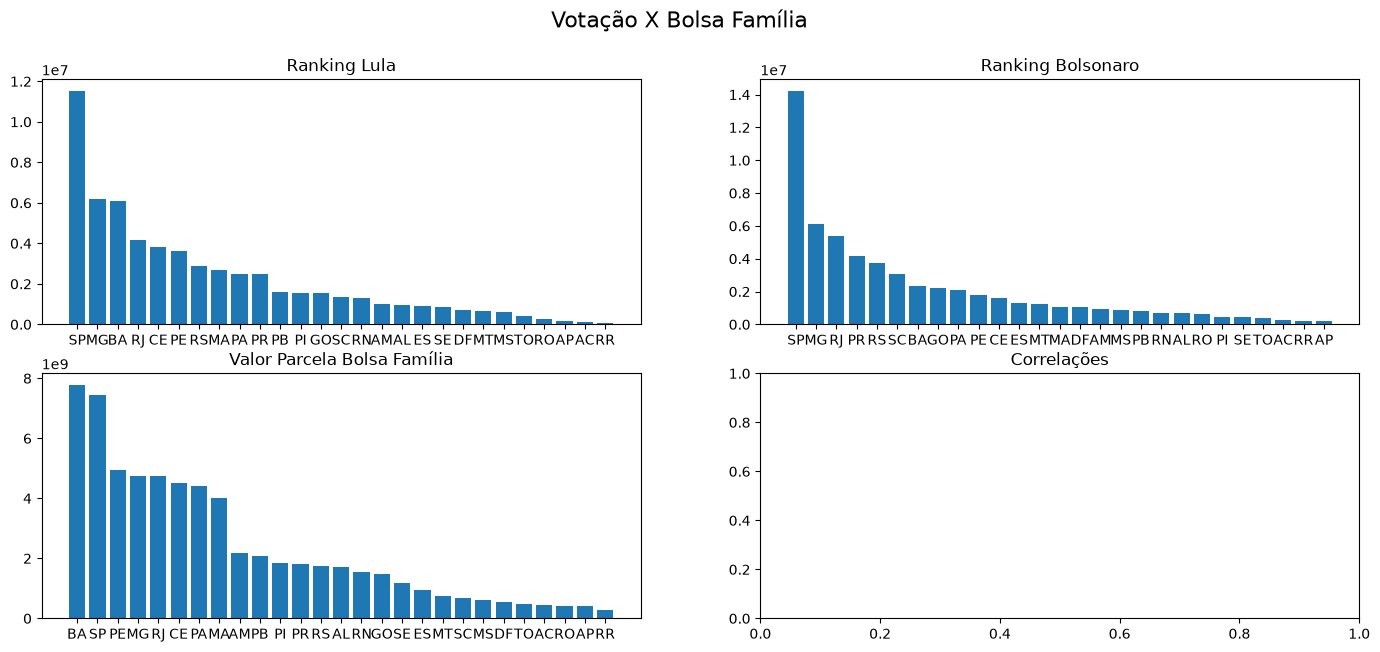

In [80]:
# vizualizando os dados
try:
    print('Visualizando os dados')

    plt.subplots(2, 2, figsize= (17, 7))
    plt.suptitle('Votação X Bolsa Família', fontsize=16)

    # posição 1: Ranking Lula
    plt.subplot(2, 2, 1)
    df_lula = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'LUIZ INÁCIO LULA DA SILVA')
    df_lula = df_lula.sort('QT_VOTOS', descending=True)

    # Gráfico de Colunas
    plt.bar(df_lula['SG_UF'], df_lula['QT_VOTOS'])
    plt.title('Ranking Lula')




    # Posição 2: Ranking Bolsonaro
    plt.subplot(2, 2, 2)
    df_bolsonaro = df_votos_bolsa_familia.filter(pl.col('NM_VOTAVEL') == 'JAIR MESSIAS BOLSONARO')
    df_bolsonaro = df_bolsonaro.sort('QT_VOTOS', descending=True)

    # Gráfico de Colunas
    plt.bar(df_bolsonaro['SG_UF'], df_bolsonaro['QT_VOTOS'])
    plt.title('Ranking Bolsonaro')




    # Posição 3: Ranking Bolsa Família
    plt.subplot(2, 2, 3)
    plt.title('Valor Parcela Bolsa Família')

    # Gráfico de Colunas
    # df_bolsa_familia = df_bolsa_familia.collect()
    df_bolsa_familia = df_bolsa_familia.sort('VALOR PARCELA', descending=True)
    plt.bar(df_bolsa_familia['UF'], df_bolsa_familia['VALOR PARCELA'])




    # Posição 4: Correlação
    plt.subplot(2, 2, 4)
    plt.title('Correlações')

    for candidato, correlacao in dict_correlacoes.items():
        plt.text(x, y , f'{candidato}: {correlacao:.2f}', fontsize=12)

        y = y - 0.2
        x = x -= 0.2




except Exception as e:
    print(f'Erro ao visualizar os dados: {e}')